# 80 FLUX.2 resolution: input resize and output upscale

Question: our heatmap is ~1235x100 (freq bins x lasers), the target mask/photo is
~1337x1110 (the box's real, squashed-to-per-box aspect crop) -- both get resized
toward FLUX.2's own bucket resolution before the VAE, which is very likely why the
wandb-logged generated images look "really rectangular": the heatmap in particular
gets squashed into a near-square shape it was never meant to have.

This notebook is purely visual/diagnostic, no training:
1. Show the raw heatmap and raw target at their true sizes and aspect ratios.
2. Show what each looks like resized to a few candidate FIXED SQUARE resolutions
   (what would actually go into the VAE/transformer).
3. Show what a generated-at-square-resolution output looks like once upscaled back
   to the target's true (box-specific) H x W, using upsample_mask's approach
   (NEAREST for masks -- never invent a gradient the source didn't have), compared
   side by side with the real original-resolution target.

No model inference here -- we don't have a trained checkpoint from the current run
yet. Step 3 uses the REAL ground-truth target resized down then back up, as a proxy
for "what does round-tripping through a fixed square resolution cost us," which is
exactly the lossy step a generated output would also go through.

In [1]:
import sys
from pathlib import Path

import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

REPO = Path.cwd().parent
for p in (str(REPO), str(REPO / "src")):
    if p not in sys.path:
        sys.path.insert(0, p)

sys.path.insert(0, str(REPO / "src2"))
from data import fft_to_heatmap, find_fft, BOX_DIRS, MASK_NAME, PHOTO_NAME

BOX = "gastronorm"
samples_dir = BOX_DIRS[BOX]
sample_dirs = sorted(p for p in samples_dir.glob("*") if p.is_dir())
# first sample with a real fft + mask + photo, for a concrete example
# pick a sample with a REAL (non-empty) object mask, not just any complete sample --
# an empty-box mask round-trips at trivial IoU=1.0 regardless of resolution.
import numpy as np
def has_object(d):
    if find_fft(d) is None or not (d / MASK_NAME).exists(): return False
    arr = np.asarray(Image.open(d / MASK_NAME).convert("L"), dtype=np.float32)
    return (arr > 0).mean() > 0.001
sample_dir = next(d for d in sample_dirs if has_object(d))
print(f"using sample: {sample_dir.name}")

heatmap = fft_to_heatmap(find_fft(sample_dir))
mask = Image.open(sample_dir / MASK_NAME).convert("RGB")
photo = Image.open(sample_dir / PHOTO_NAME).convert("RGB")

print(f"heatmap: {heatmap.size} (w,h), ratio {heatmap.size[0]/heatmap.size[1]:.2f}:1")
print(f"mask:    {mask.size} (w,h), ratio {mask.size[0]/mask.size[1]:.2f}:1")
print(f"photo:   {photo.size} (w,h), ratio {photo.size[0]/photo.size[1]:.2f}:1")

using sample: 000041
heatmap: (1235, 100) (w,h), ratio 12.35:1
mask:    (1337, 1110) (w,h), ratio 1.20:1
photo:   (1337, 1110) (w,h), ratio 1.20:1


## 1. Raw images at true size

The heatmap's aspect ratio (~12:1) is nothing like the target's (~1.2:1) -- these
are fundamentally different-shaped images being forced through the same
resize/bucket pipeline today.

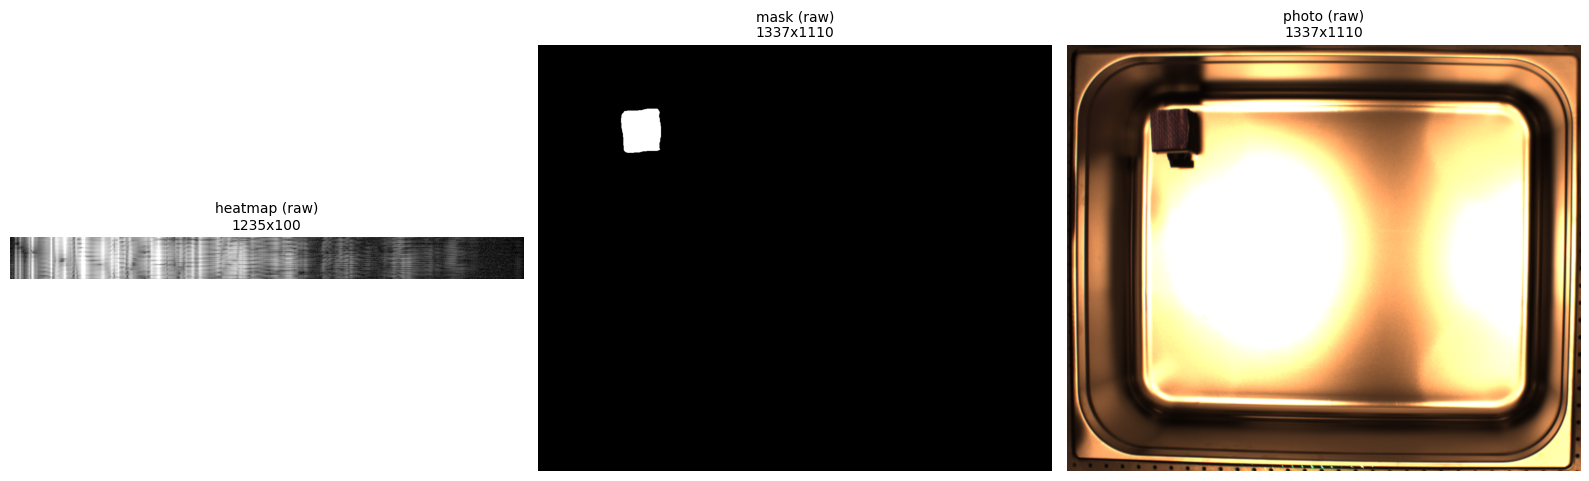

In [2]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, img, title in zip(axes, [heatmap, mask, photo], ["heatmap (raw)", "mask (raw)", "photo (raw)"]):
    ax.imshow(img)
    ax.set_title(f"{title}\n{img.size[0]}x{img.size[1]}", fontsize=10)
    ax.axis("off")
fig.tight_layout()
plt.show()

## 2. Resized to candidate fixed square resolutions

Candidates to compare: 256, 512, 768 (all square -- matches FLUX.2 klein's
documented LoRA training resolutions from the BFL blog: 256/512/768/1024/1280/1536).
For the heatmap, naive resize massively distorts it (12:1 -> 1:1); padding to
square (keep the heatmap's own aspect, pad the short axis) preserves its actual
shape instead of destroying it -- compare both.

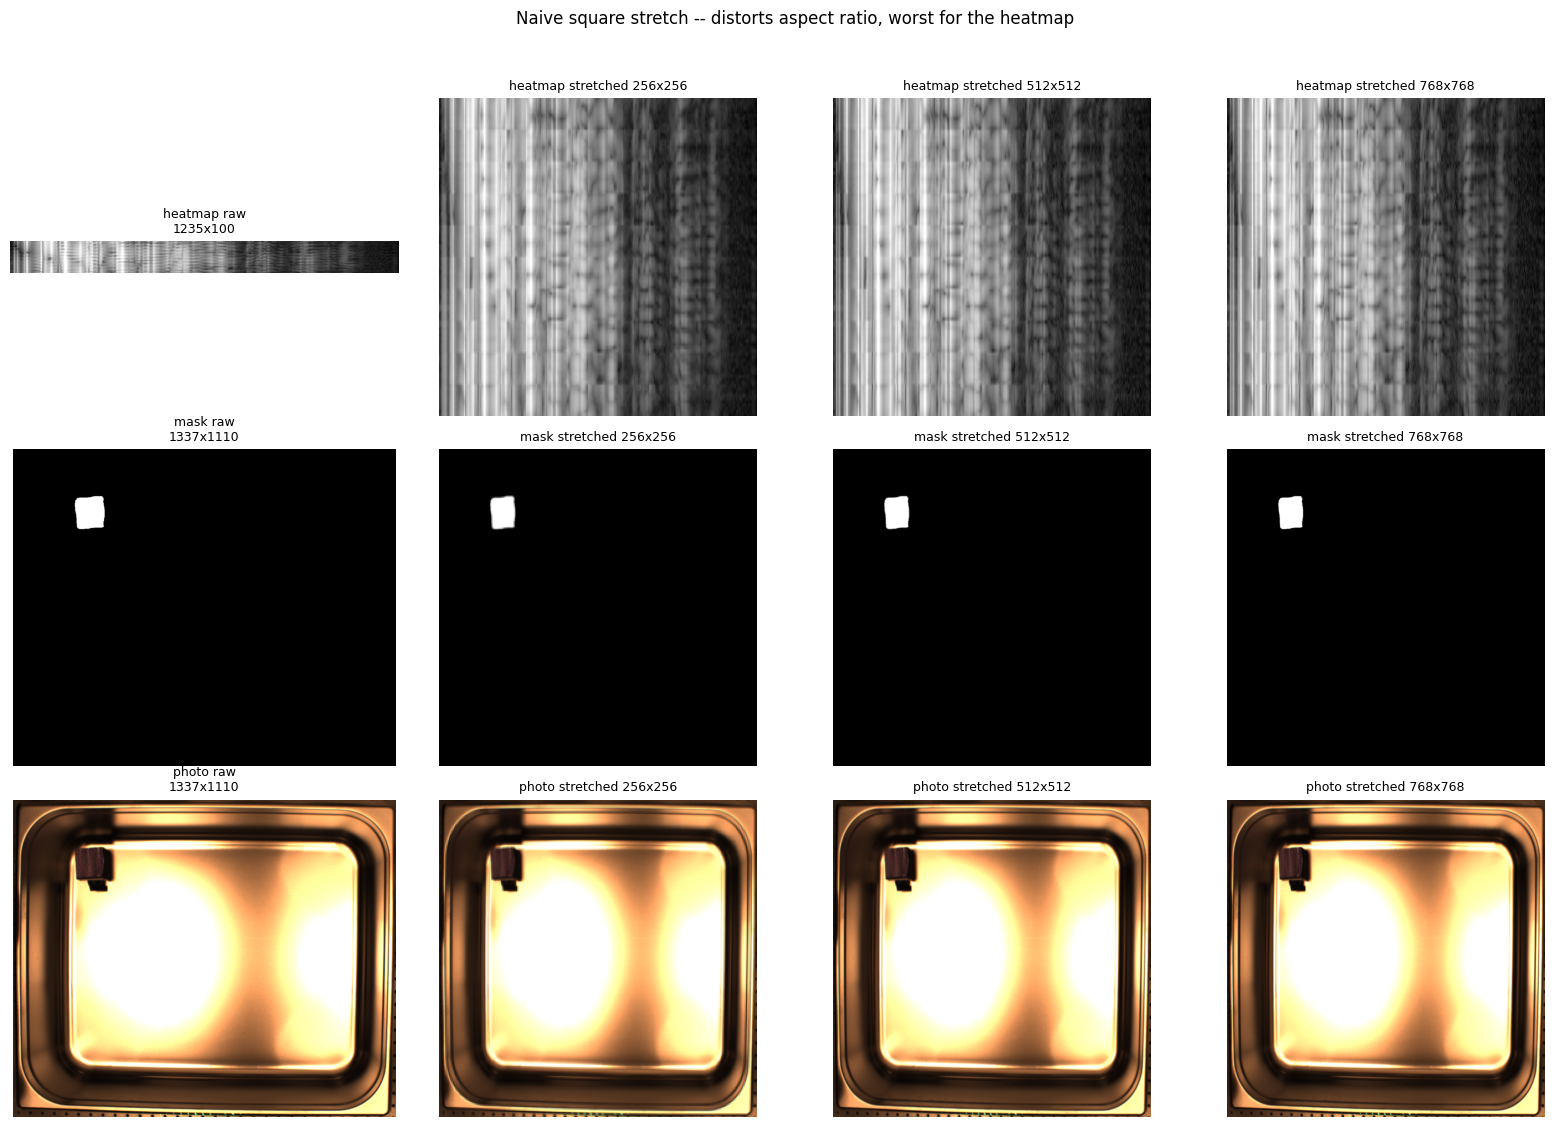

In [3]:
def resize_square_stretch(img, size):
    """Naive: resize width and height independently to size x size -- distorts
    aspect ratio. This is close to what a bucket-based resize pipeline does when
    it forces a bucket shape."""
    return img.resize((size, size), Image.BILINEAR)


def resize_square_pad(img, size, fill=0):
    """Preserve aspect ratio: scale to fit inside size x size, pad the rest.
    Keeps the heatmap's true (L,F) shape legible instead of squashing it."""
    w, h = img.size
    scale = size / max(w, h)
    new_w, new_h = round(w * scale), round(h * scale)
    resized = img.resize((new_w, new_h), Image.BILINEAR)
    canvas = Image.new(img.mode, (size, size), fill)
    canvas.paste(resized, ((size - new_w) // 2, (size - new_h) // 2))
    return canvas


CANDIDATE_SIZES = [256, 512, 768]

fig, axes = plt.subplots(3, len(CANDIDATE_SIZES) + 1, figsize=(4 * (len(CANDIDATE_SIZES) + 1), 11))
for row, (img, name) in enumerate([(heatmap, "heatmap"), (mask, "mask"), (photo, "photo")]):
    axes[row, 0].imshow(img)
    axes[row, 0].set_title(f"{name} raw\n{img.size[0]}x{img.size[1]}", fontsize=9)
    axes[row, 0].axis("off")
    for col, size in enumerate(CANDIDATE_SIZES, start=1):
        stretched = resize_square_stretch(img, size)
        axes[row, col].imshow(stretched)
        axes[row, col].set_title(f"{name} stretched {size}x{size}", fontsize=9)
        axes[row, col].axis("off")
fig.suptitle("Naive square stretch -- distorts aspect ratio, worst for the heatmap", y=1.02)
fig.tight_layout()
plt.show()

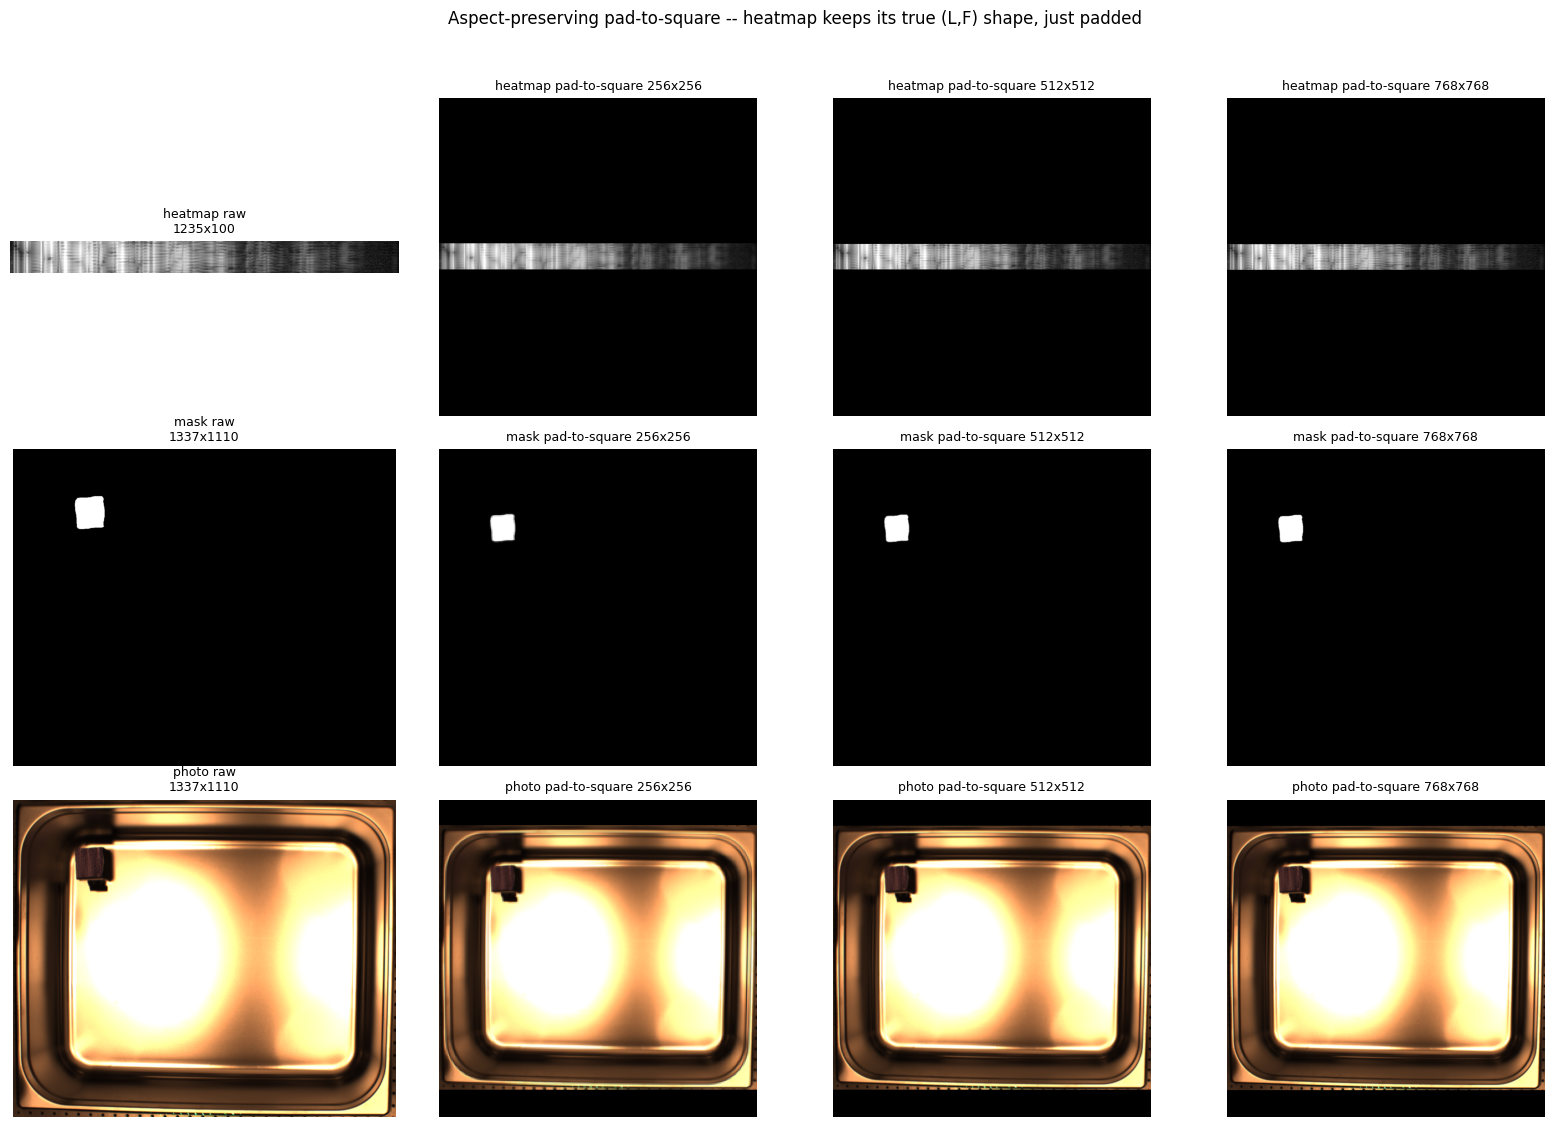

In [4]:
fig, axes = plt.subplots(3, len(CANDIDATE_SIZES) + 1, figsize=(4 * (len(CANDIDATE_SIZES) + 1), 11))
for row, (img, name) in enumerate([(heatmap, "heatmap"), (mask, "mask"), (photo, "photo")]):
    axes[row, 0].imshow(img)
    axes[row, 0].set_title(f"{name} raw\n{img.size[0]}x{img.size[1]}", fontsize=9)
    axes[row, 0].axis("off")
    for col, size in enumerate(CANDIDATE_SIZES, start=1):
        padded = resize_square_pad(img, size)
        axes[row, col].imshow(padded)
        axes[row, col].set_title(f"{name} pad-to-square {size}x{size}", fontsize=9)
        axes[row, col].axis("off")
fig.suptitle("Aspect-preserving pad-to-square -- heatmap keeps its true (L,F) shape, just padded", y=1.02)
fig.tight_layout()
plt.show()

## 3. Round-trip cost: square resolution -> upscale back to true box size

This simulates what happens to a MASK target if the model only ever sees/produces
a fixed square resolution: downsample the real mask to a square (what the model
would train against), then upsample it back to the box's TRUE H x W using
`upsample_mask`'s NEAREST-based approach (matches `src/model/dataset.py`, never
invents a gradient the source didn't have), and compare against the real original.

This does NOT run the trained model -- there's no checkpoint yet from the live
100-epoch run. It isolates the resize round-trip's own information loss, which is
a lower bound on what a real generated-then-upscaled output would lose (a real
model adds its own approximation error on top of this).

/home/ethantu/workspace/good-vibrations/.venv/lib/python3.12/site-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


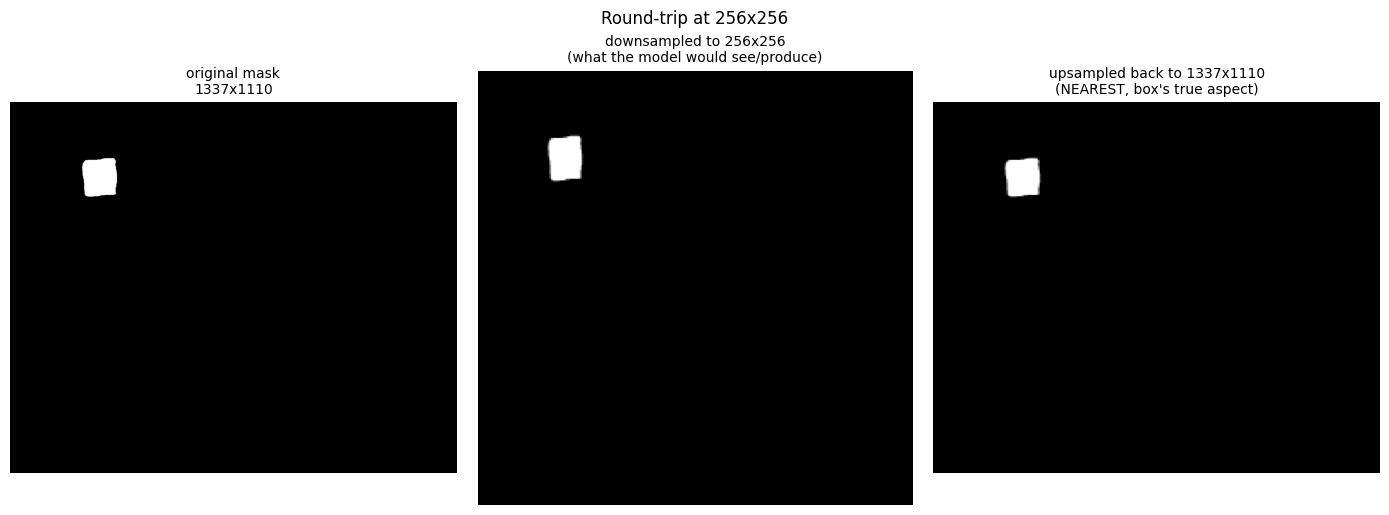

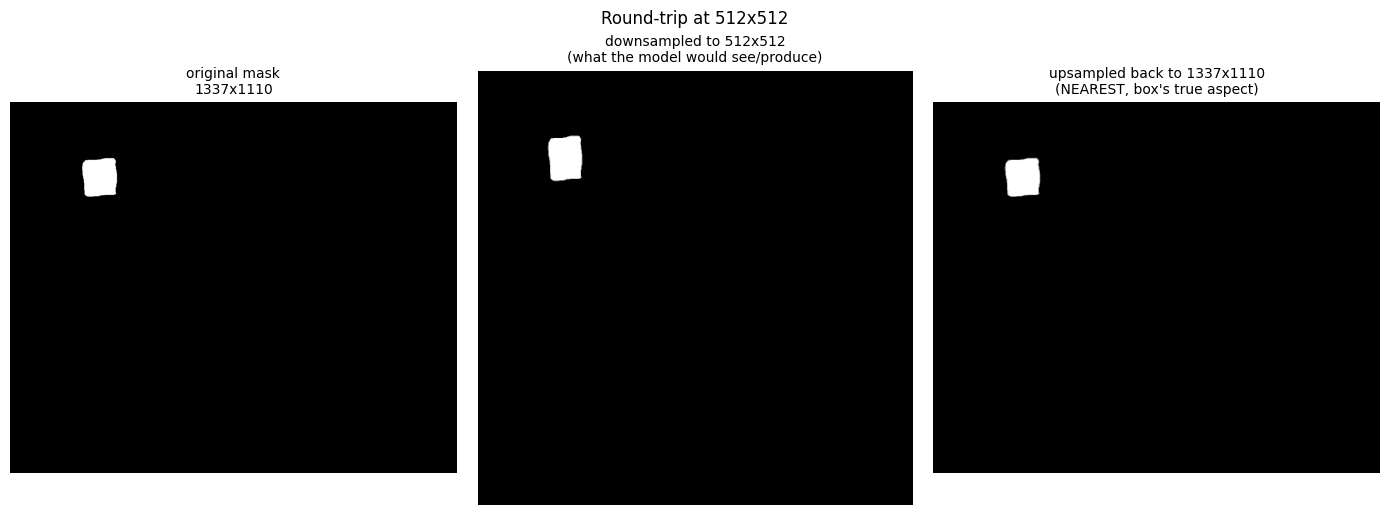

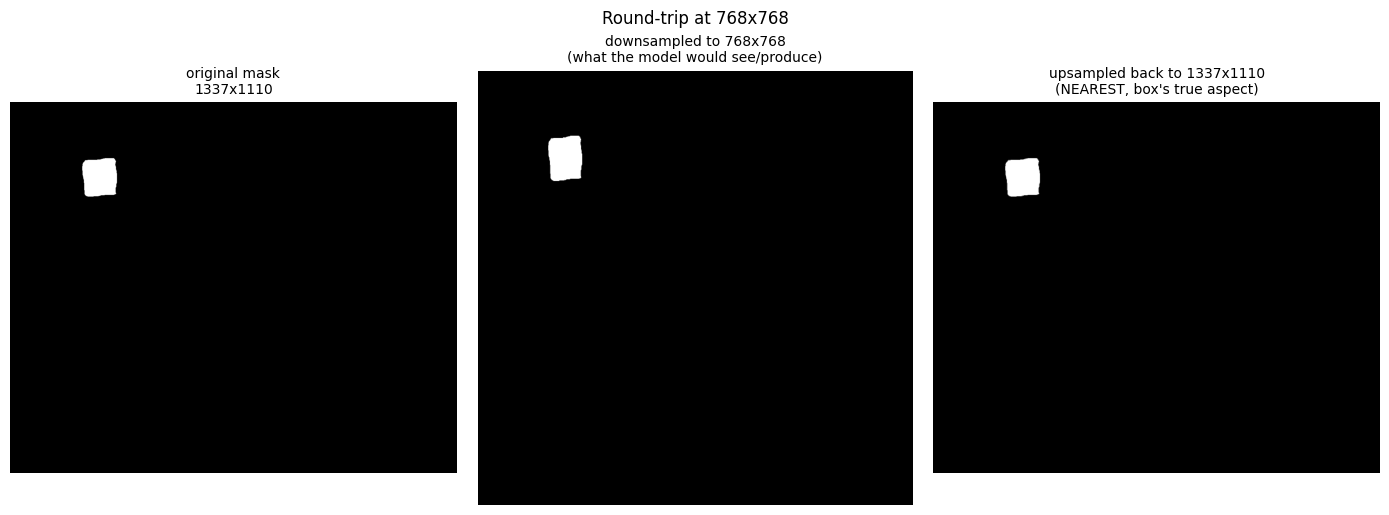

In [5]:
from model.dataset import downsample_mask, upsample_mask

box_w, box_h = mask.size  # this sample's TRUE full-res box crop size

for size in CANDIDATE_SIZES:
    down = downsample_mask(mask, size, size, rgb=True)  # (size,size,3) float [0,1]
    back_up = upsample_mask(down, box_w, box_h, smooth=False)  # NEAREST, true box_w x box_h

    fig, axes = plt.subplots(1, 3, figsize=(14, 5))
    axes[0].imshow(mask)
    axes[0].set_title(f"original mask\n{box_w}x{box_h}", fontsize=10)
    axes[0].axis("off")
    axes[1].imshow(down)
    axes[1].set_title(f"downsampled to {size}x{size}\n(what the model would see/produce)", fontsize=10)
    axes[1].axis("off")
    axes[2].imshow(back_up)
    axes[2].set_title(f"upsampled back to {box_w}x{box_h}\n(NEAREST, box's true aspect)", fontsize=10)
    axes[2].axis("off")
    fig.suptitle(f"Round-trip at {size}x{size}", y=1.02)
    fig.tight_layout()
    plt.show()

In [6]:
from utils.metrics import soft_iou
import torch

print("Round-trip fidelity (soft IoU between original and round-tripped mask):")
mask_arr = np.asarray(mask, dtype=np.float32).mean(-1) / 255.0
for size in CANDIDATE_SIZES:
    down = downsample_mask(mask, size, size, rgb=True)
    back_up = upsample_mask(down, box_w, box_h, smooth=False)
    back_up_gray = back_up.mean(-1) if back_up.ndim == 3 else back_up
    iou = soft_iou(torch.from_numpy(back_up_gray).unsqueeze(0), torch.from_numpy(mask_arr).unsqueeze(0)).item()
    print(f"  {size}x{size}: soft_iou = {iou:.4f}")

Round-trip fidelity (soft IoU between original and round-tripped mask):
  256x256: soft_iou = 0.9428
  512x512: soft_iou = 0.9762
  768x768: soft_iou = 0.9881


## Reading this

- **Naive square stretch** is what a bucket-resize pipeline effectively does today
  when it forces every image toward one square-ish bucket -- catastrophic for the
  heatmap (12:1 -> 1:1), which is very likely the direct cause of the "really
  rectangular" generated images: the model is learning on a heatmap whose real
  shape it never actually sees.
- **Pad-to-square** preserves the heatmap's true shape (visible bands stay at
  their real relative width) at the cost of wasted canvas (padding), which the
  model has to learn to ignore -- standard practice, and what I'd recommend using
  in `src2/data.py` for the conditioning heatmap specifically.
- **The round-trip IoU numbers** quantify the real cost of choosing a low fixed
  resolution for the TARGET (mask/photo): if 256x256 round-trips at high IoU (close
  to 1.0) for this box's real geometry, that's a safe choice; if it's meaningfully
  lower, a bigger fixed resolution (512+) is worth the extra compute.
- Note this box's specific `box_w x box_h` (`{box_w}x{box_h}` from the printout
  above) is squashed differently per box (gastronorm vs. shoebox vs. cardboard all
  differ) -- `upsample_mask` un-squashes per-box using `box_geometry.json`, exactly
  the mechanism to reuse for un-squashing FLUX.2's generated output at inference
  time, once we pick a fixed training resolution.